# Suitability Constraints

## 1. Disadvantaged Agricultural Areas

**Dataset:** Benachteiligte Gebiete (EWG 1997)  
**Source:** LEL / LUBW Energieatlas Baden-Württemberg  
**Format:** ESRI Shapefile  
**Underlying designation:** Historical disadvantaged-area boundaries (1986/1997)

### Purpose

The dataset represents agriculturally disadvantaged areas used as a
potentially suitable-area criterion in the Baden-Württemberg
ground-mounted photovoltaic screening framework.

### Important limitation

The dataset is intended for regional spatial analysis and is not an
official legally binding representation of parcel-level eligibility.
Where only part of a cadastral district (Gemarkung) is classified as
disadvantaged, binding information on the affected parcels must be
obtained from the responsible lower agricultural authority.

### Use in this project

The dataset is used only for regional PV site screening and not for
parcel-level legal eligibility assessment.

### Data Inspection

In [1]:
from pathlib import Path

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import rasterio

In [2]:
AGRI_PATH = Path(
    "../data/raw/Benachteiligte_Gebiete_BW_1986_1997/Benachteiligte_Gebiete_EWG1997.shp"
)

print(AGRI_PATH.exists())

True


In [12]:
agri_disadvantaged = gpd.read_file(AGRI_PATH)

In [13]:
print("Shape: ", agri_disadvantaged.shape)
print("Columns: ", agri_disadvantaged.columns.tolist())
print("Geometry Type: ", agri_disadvantaged.geom_type.value_counts())
print("Bounds:", agri_disadvantaged.total_bounds)
print("CRS", agri_disadvantaged.crs)


Shape:  (3380, 16)
Columns:  ['GEMARKUNG_', 'LANGNAME', 'GEMEINDE_N', 'GEMEINDE', 'KREIS_NR', 'KREIS', 'REGION_NR', 'REGION', 'REG_BEZ_NR', 'REG_BEZ', 'BUNDESLAND', 'BUNDESLA_1', 'BEN_GEBIET', 'BEN_GEBI_1', 'BEMERKUNG', 'geometry']
Geometry Type:  Polygon         3059
MultiPolygon     321
Name: count, dtype: int64
Bounds: [ 388338.52104232 5265155.5809053   610073.24694312 5515628.43612693]
CRS EPSG:25832


In [14]:
agri_disadvantaged.head(5)

,GEMARKUNG_,LANGNAME,GEMEINDE_N,GEMEINDE,KREIS_NR,KREIS,REGION_NR,REGION,REG_BEZ_NR,REG_BEZ,BUNDESLAND,BUNDESLA_1,BEN_GEBIET,BEN_GEBI_1,BEMERKUNG,geometry
0,3462,Landshausen,8215097,Kraichtal,8215.0,Karlsruhe,821.0,Region Mittlerer Oberrhein,82.0,Reg.-Bez. Karlsruhe,8.0,Baden-Württemberg,0,ohne benachteiligte Gebiete,NaN,"POLYGON ((486722.179 5444938.419, 486801.168 5..."
1,3467,Oberöwisheim,8215097,Kraichtal,8215.0,Karlsruhe,821.0,Region Mittlerer Oberrhein,82.0,Reg.-Bez. Karlsruhe,8.0,Baden-Württemberg,0,ohne benachteiligte Gebiete,NaN,"POLYGON ((478504.449 5446557.087, 478566.894 5..."
2,3371,Mingolsheim,8215100,Bad Schönborn,8215.0,Karlsruhe,821.0,Region Mittlerer Oberrhein,82.0,Reg.-Bez. Karlsruhe,8.0,Baden-Württemberg,0,ohne benachteiligte Gebiete,NaN,"POLYGON ((472966.916 5454518.714, 472975.882 5..."
3,3370,Langenbrücken,8215100,Bad Schönborn,8215.0,Karlsruhe,821.0,Region Mittlerer Oberrhein,82.0,Reg.-Bez. Karlsruhe,8.0,Baden-Württemberg,0,ohne benachteiligte Gebiete,NaN,"POLYGON ((476513.012 5450316.078, 476603.776 5..."
4,3543,Wöschbach,8215101,Pfinztal,8215.0,Karlsruhe,821.0,Region Mittlerer Oberrhein,82.0,Reg.-Bez. Karlsruhe,8.0,Baden-Württemberg,0,ohne benachteiligte Gebiete,NaN,"POLYGON ((468112.796 5428314.495, 468163.726 5..."


In [15]:
agri_disadvantaged["BEN_GEBIET"].unique()

array([ 0, -1,  1])

In [16]:
agri_disadvantaged["BEN_GEBI_1"].unique()

<StringArray>
[       'ohne benachteiligte Gebiete',    'mit benachteiligten Teilflächen',
 'vollständig benachteiligtes Gebiet']
Length: 3, dtype: str

Mapping between BEN_GEBIET and BEN_GEBI_1

In [17]:
print(agri_disadvantaged[["BEN_GEBIET", "BEN_GEBI_1"]].drop_duplicates())

    BEN_GEBIET                          BEN_GEBI_1
0            0         ohne benachteiligte Gebiete
18          -1     mit benachteiligten Teilflächen
23           1  vollständig benachteiligtes Gebiet


Inspecting NA/Missing/Invalid values in the dataset

In [18]:
agri_disadvantaged.isna().sum()

GEMARKUNG_       0
LANGNAME         0
GEMEINDE_N       0
GEMEINDE         0
KREIS_NR         0
KREIS            0
REGION_NR        0
REGION           0
REG_BEZ_NR       0
REG_BEZ          0
BUNDESLAND       0
BUNDESLA_1       0
BEN_GEBIET       0
BEN_GEBI_1       0
BEMERKUNG     3367
geometry         0
dtype: int64

In [19]:
agri_disadvantaged.geometry.isna().sum()

np.int64(0)

In [20]:
(~agri_disadvantaged.geometry.is_valid).sum()

np.int64(14)

Inspecting the invalid comments

In [21]:
agri_disadvantaged.loc[
    agri_disadvantaged["BEMERKUNG"].notna(),
    ["LANGNAME", "BEN_GEBIET", "BEN_GEBI_1", "BEMERKUNG"]
]

,LANGNAME,BEN_GEBIET,BEN_GEBI_1,BEMERKUNG
252,Altbach,1,vollständig benachteiligtes Gebiet,ohne Ortslage
266,Kirchheim,1,vollständig benachteiligtes Gebiet,ohne Ortslage
953,Baden-Baden,1,vollständig benachteiligtes Gebiet,ohne Ortslage
1385,Schwäbisch Hall,1,vollständig benachteiligtes Gebiet,ohne Ortslage
1636,Konstanz,1,vollständig benachteiligtes Gebiet,ohne Ortslage
1643,Radolfzell,1,vollständig benachteiligtes Gebiet,ohne Ortslage
1839,Plochingen,1,vollständig benachteiligtes Gebiet,ohne Ortslage
2196,Esslingen,1,vollständig benachteiligtes Gebiet,ohne Ortslage
2226,Singen,1,vollständig benachteiligtes Gebiet,ohne Ortslage
2415,Säckingen,1,vollständig benachteiligtes Gebiet,ohne Ortslage


Inspecting the invalid geometries.

In [22]:
invalid_agri = agri_disadvantaged[
    ~agri_disadvantaged.geometry.is_valid
].copy()

invalid_agri[
    ["LANGNAME", "BEN_GEBIET", "BEN_GEBI_1"]
]

,LANGNAME,BEN_GEBIET,BEN_GEBI_1
35,Cresbach,1,vollständig benachteiligtes Gebiet
50,Untersteinbach,1,vollständig benachteiligtes Gebiet
1291,Gebrazhofen,1,vollständig benachteiligtes Gebiet
1570,Binningen,1,vollständig benachteiligtes Gebiet
1612,Bolstern,-1,mit benachteiligten Teilflächen
1692,Mögglingen,1,vollständig benachteiligtes Gebiet
1702,Herlikofen,1,vollständig benachteiligtes Gebiet
2150,Neuravensburg,1,vollständig benachteiligtes Gebiet
2177,Kuppingen,1,vollständig benachteiligtes Gebiet
2334,St. Märgen,1,vollständig benachteiligtes Gebiet


In [23]:
invalid_agri.geometry.is_valid_reason().value_counts()

Ring Self-intersection[469186.010115057 5373511.32956383]    1
Ring Self-intersection[541662.360900022 5444285.79925429]    1
Ring Self-intersection[572974.893726173 5288866.67374721]    1
Ring Self-intersection[480623.767060482 5294039.85028397]    1
Ring Self-intersection[535852.673829512 5311785.62312775]    1
Ring Self-intersection[570927.752093964 5406990.72337225]    1
Ring Self-intersection[565102.934780945 5407772.1230122]     1
Ring Self-intersection[559316.65281672 5277681.75648269]     1
Ring Self-intersection[485614.535258421 5384348.17783505]    1
Ring Self-intersection[431483.039928721 5314789.325335]      1
Ring Self-intersection[432758.156065507 5382003.61045505]    1
Ring Self-intersection[532256.280713728 5416641.60348036]    1
Ring Self-intersection[524582.686228084 5436306.8101567]     1
Ring Self-intersection[500310.19728233 5461835.67853151]     1
Name: count, dtype: int64

In [24]:
agri_clean = agri_disadvantaged.copy()

agri_clean["geometry"] = agri_clean.geometry.make_valid()

In [25]:
print("Invalid before:",
      (~agri_disadvantaged.geometry.is_valid).sum())

print("Invalid after:",
      (~agri_clean.geometry.is_valid).sum())

print("Missing after:",
      agri_clean.geometry.isna().sum())

Invalid before: 14
Invalid after: 0
Missing after: 0


In [26]:
agri_clean.geom_type.value_counts()

Polygon         3059
MultiPolygon     321
Name: count, dtype: int64

### Geometry validation

The dataset contains 3,380 spatial features. Initial geometry validation
identified 14 invalid geometries, all caused by ring self-intersections.
No geometries were missing.

The invalid geometries were repaired using `make_valid()`. After repair,
all geometries were valid and the original geometry-type distribution
was preserved:

- 3,059 Polygons
- 321 MultiPolygons

The cleaned GeoDataFrame is used for subsequent spatial operations.

In [27]:
agri_clean.value_counts(subset=["BEN_GEBI_1"])

BEN_GEBI_1                        
vollständig benachteiligtes Gebiet    1965
ohne benachteiligte Gebiete            872
mit benachteiligten Teilflächen        543
Name: count, dtype: int64

This dataset does not necessarily tell us which individual parcels are disadvantaged. Binding parcel-level information has to come from the relevant agricultural authority. So we will only consider "vollständig benachteiligtes Gebiet"  / completely disdvantaged area

In [28]:
agri_candidates = agri_clean[
    agri_clean["BEN_GEBIET"] == 1
].copy()

In [29]:
print("Shape: ", agri_candidates.shape)
print("Geometry Type: ", agri_candidates.geom_type.value_counts())
print("CRS", agri_candidates.crs)
print("Valid geometries", agri_candidates.geometry.is_valid.sum())

Shape:  (1965, 16)
Geometry Type:  Polygon         1830
MultiPolygon     135
Name: count, dtype: int64
CRS EPSG:25832
Valid geometries 1965


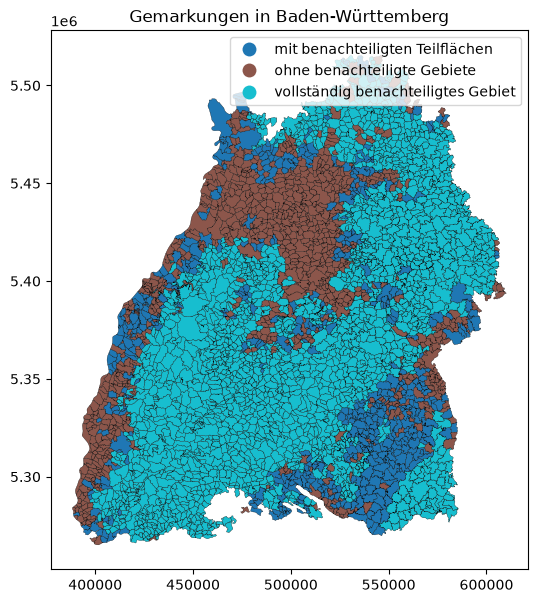

In [30]:
# Color countries by population
ax = agri_clean.plot(
    column='BEN_GEBI_1', 
    categorical=True,      # Column to color by
    
    legend=True,            # Show legend
    edgecolor='black',
    linewidth=0.2,      # Outline color
    figsize=(9, 7)
)

plt.title("Gemarkungen in Baden-Württemberg")
plt.show()


The completely disadvantaged Gemarkungen seem especially widespread through much of the south, southwest, east and northeast.
The non-disadvantaged Gemarkungen appear much more concentrated through a broad central/northwestern belt.
And the partially disadvantaged ones aren't randomly distributed either; there are noticeable clusters, particularly around portions of the south/southeast and west/northwest.

The designation has substantial spatial structure. It isn't just a random property attached to Gemarkungen

In [31]:
agri_clean.head(5)

,GEMARKUNG_,LANGNAME,GEMEINDE_N,GEMEINDE,KREIS_NR,KREIS,REGION_NR,REGION,REG_BEZ_NR,REG_BEZ,BUNDESLAND,BUNDESLA_1,BEN_GEBIET,BEN_GEBI_1,BEMERKUNG,geometry
0,3462,Landshausen,8215097,Kraichtal,8215.0,Karlsruhe,821.0,Region Mittlerer Oberrhein,82.0,Reg.-Bez. Karlsruhe,8.0,Baden-Württemberg,0,ohne benachteiligte Gebiete,NaN,"POLYGON ((486722.179 5444938.419, 486801.168 5..."
1,3467,Oberöwisheim,8215097,Kraichtal,8215.0,Karlsruhe,821.0,Region Mittlerer Oberrhein,82.0,Reg.-Bez. Karlsruhe,8.0,Baden-Württemberg,0,ohne benachteiligte Gebiete,NaN,"POLYGON ((478504.449 5446557.087, 478566.894 5..."
2,3371,Mingolsheim,8215100,Bad Schönborn,8215.0,Karlsruhe,821.0,Region Mittlerer Oberrhein,82.0,Reg.-Bez. Karlsruhe,8.0,Baden-Württemberg,0,ohne benachteiligte Gebiete,NaN,"POLYGON ((472966.916 5454518.714, 472975.882 5..."
3,3370,Langenbrücken,8215100,Bad Schönborn,8215.0,Karlsruhe,821.0,Region Mittlerer Oberrhein,82.0,Reg.-Bez. Karlsruhe,8.0,Baden-Württemberg,0,ohne benachteiligte Gebiete,NaN,"POLYGON ((476513.012 5450316.078, 476603.776 5..."
4,3543,Wöschbach,8215101,Pfinztal,8215.0,Karlsruhe,821.0,Region Mittlerer Oberrhein,82.0,Reg.-Bez. Karlsruhe,8.0,Baden-Württemberg,0,ohne benachteiligte Gebiete,NaN,"POLYGON ((468112.796 5428314.495, 468163.726 5..."
